<a href="https://colab.research.google.com/github/Mareeyan/DataMining-Phase2/blob/main/DataMining_Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

data_url = 'https://raw.githubusercontent.com/Mareeyan/DataMining-Phase2/refs/heads/main/synthetic_disaster_events_2025.csv'
df = pd.read_csv(data_url)

print(df.head(10))

   event_id      disaster_type   location   latitude   longitude        date  \
0         1           Wildfire      Chile -34.681672  -71.819529  2025-08-27   
1         2          Hurricane      India  22.128569   78.023951  2023-05-29   
2         3  Volcanic Eruption      Italy  42.316058   11.031447  2023-01-15   
3         4            Drought      Chile -33.436253  -69.984615  2024-02-08   
4         5  Volcanic Eruption     Turkey  39.400977   37.006822  2023-12-23   
5         6           Wildfire  Indonesia  -2.476140  112.894649  2023-11-19   
6         7            Drought      India  19.975275   78.004552  2023-07-12   
7         8  Volcanic Eruption      Japan  37.140390  139.725145  2023-05-16   
8         9          Hurricane     Turkey  41.048683   34.174467  2025-10-24   
9        10            Drought        USA  34.125352  -96.170595  2025-04-03   

   severity_level  affected_population  estimated_economic_loss_usd  \
0               8                31104          

Outliers in estimated_economic_loss_usd: 268


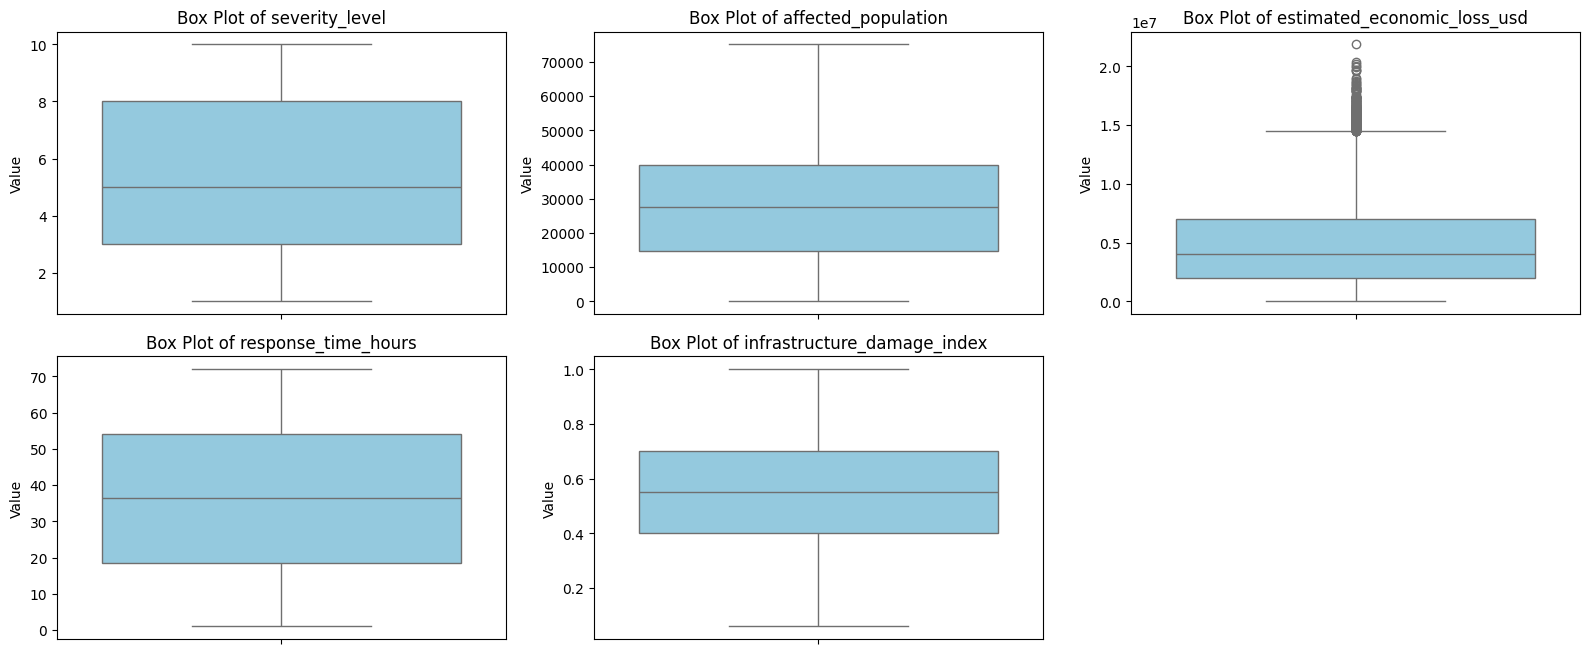

In [ ]:
# IDENTIFYING OUTLIERS USING BOX PLOTS
cols_to_plot = ['severity_level', 'affected_population', 'estimated_economic_loss_usd',
                'response_time_hours', 'infrastructure_damage_index']

# Set up the figure and axes
plt.figure(figsize=(16, 10))

# Create boxplots for each column
for i, col in enumerate(cols_to_plot):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Box Plot of {col}')
    plt.ylabel('Value')

plt.tight_layout()

Q1 = df['estimated_economic_loss_usd'].quantile(0.25)
Q3 = df['estimated_economic_loss_usd'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['estimated_economic_loss_usd'] < (Q1 - 1.5 * IQR)) |
              (df['estimated_economic_loss_usd'] > (Q3 + 1.5 * IQR))]

print(f"Outliers in estimated_economic_loss_usd: {len(outliers)}")

In [ ]:
# Identify columns with missing values
print("MISSING VALUES COUNT PER COLUMN:")
print(df.isnull().sum())

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nNUMERICAL COLUMNS: {numerical_cols}")
print(f"CATEGORICAL COLUMNS: {categorical_cols}")

# Remove numerical columns with more than 50% missing data
print("\nMISSING VALUES PERCENTAGE PER COLUMN:")
print((df.isnull().sum() / len(df)) * 100)
missing_threshold = 0.5
cols_to_drop = [col for col in df.columns if df[col].isnull().mean() > missing_threshold]
df.drop(columns=cols_to_drop, inplace=True)
print(f"\nDropped columns (>50% missing): {cols_to_drop}")

MISSING VALUES COUNT PER COLUMN:
event_id                       0
disaster_type                  0
location                       0
latitude                       0
longitude                      0
date                           0
severity_level                 0
affected_population            0
estimated_economic_loss_usd    0
response_time_hours            0
aid_provided                   0
infrastructure_damage_index    0
is_major_disaster              0
dtype: int64

NUMERICAL COLUMNS: ['event_id', 'latitude', 'longitude', 'severity_level', 'affected_population', 'estimated_economic_loss_usd', 'response_time_hours', 'infrastructure_damage_index', 'is_major_disaster']
CATEGORICAL COLUMNS: ['disaster_type', 'location', 'date', 'aid_provided']

MISSING VALUES PERCENTAGE PER COLUMN:
event_id                       0.0
disaster_type                  0.0
location                       0.0
latitude                       0.0
longitude                      0.0
date                           

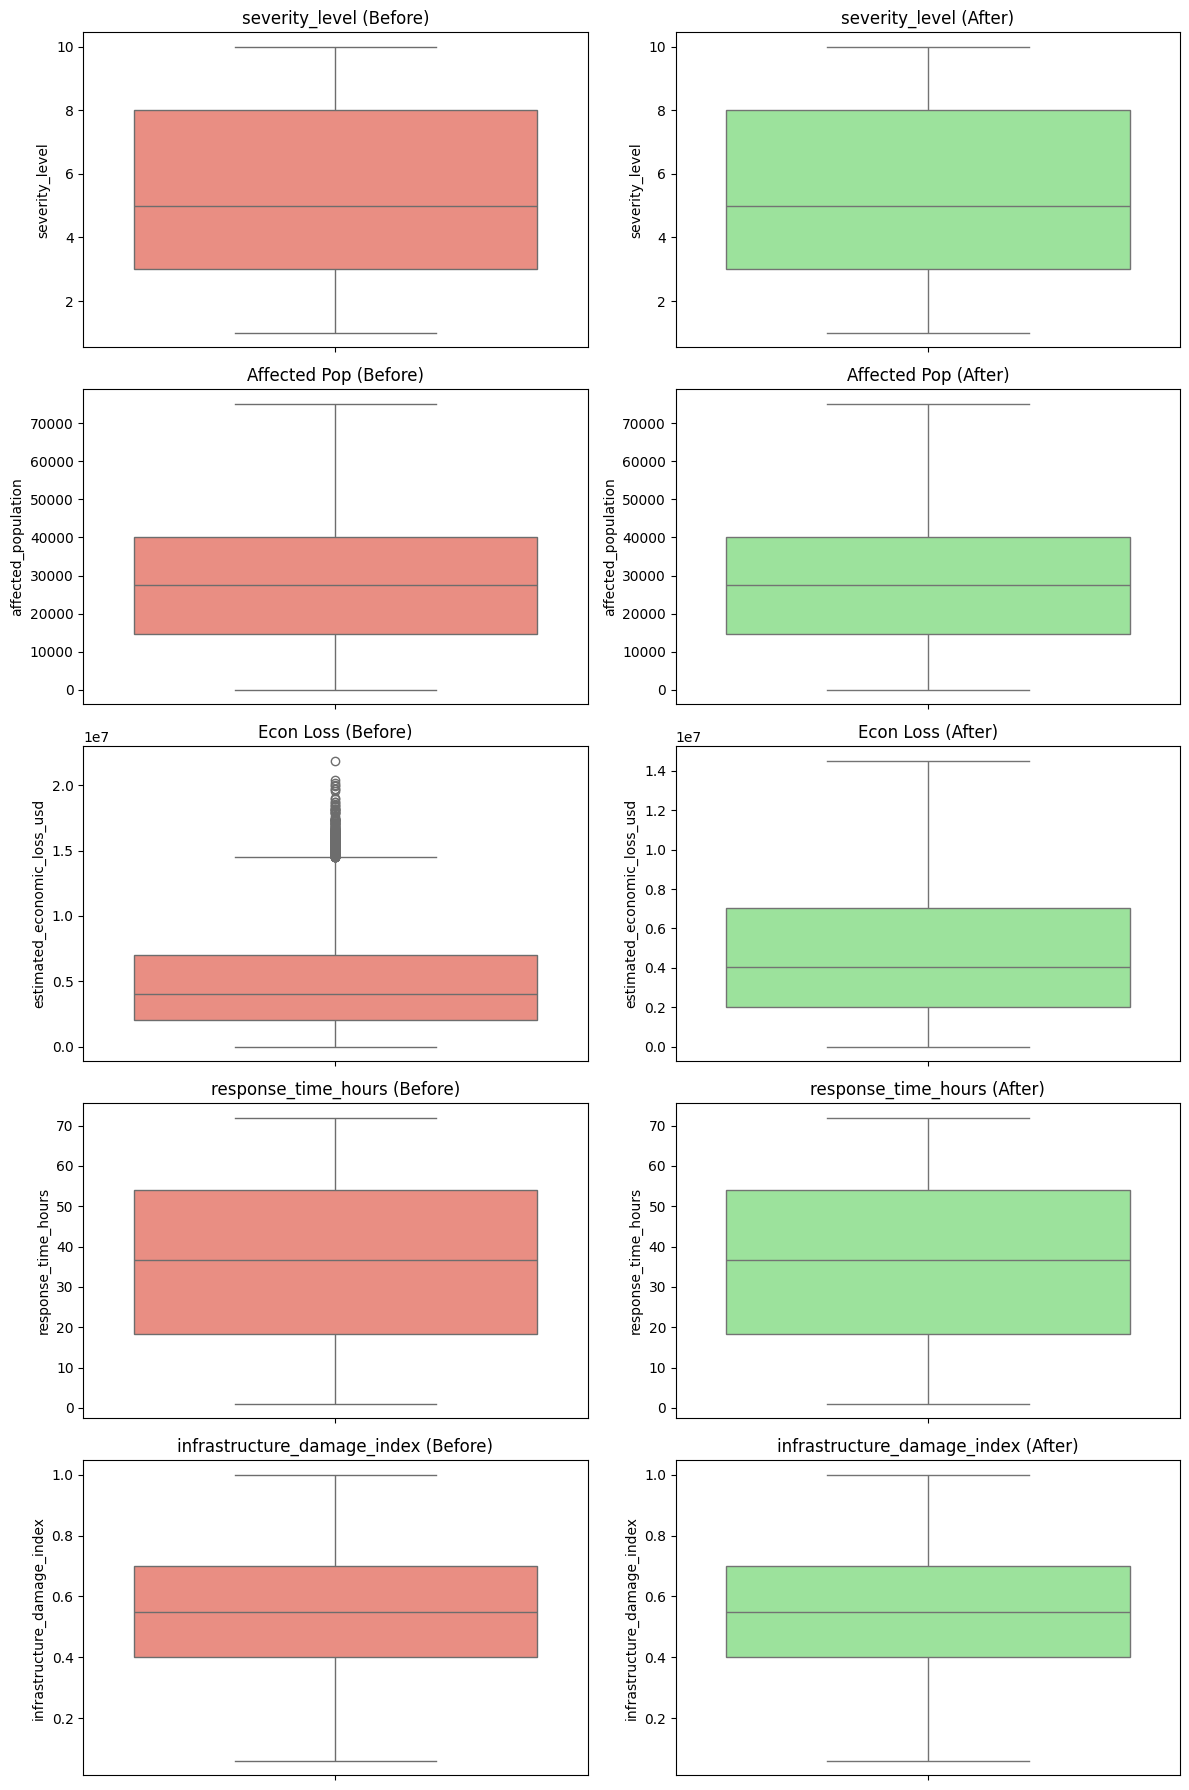

In [ ]:
#CAPPING THE COLUMNS WITH OUTLIERS

# Container for the before data
df_before = df[cols_to_plot].copy()

# Apply capping
for col in cols_to_plot:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

# Visualization: Before vs. After capping
plt.figure(figsize=(12, 18))

plt.subplot(5, 2, 1)
sns.boxplot(y=df_before['severity_level'], color='salmon')
plt.title('severity_level (Before)')

plt.subplot(5, 2, 2)
sns.boxplot(y=df['severity_level'], color='lightgreen')
plt.title('severity_level (After)')

plt.subplot(5, 2, 3)
sns.boxplot(y=df_before['affected_population'], color='salmon')
plt.title('Affected Pop (Before)')

plt.subplot(5, 2, 4)
sns.boxplot(y=df['affected_population'], color='lightgreen')
plt.title('Affected Pop (After)')

plt.subplot(5, 2, 5)
sns.boxplot(y=df_before['estimated_economic_loss_usd'], color='salmon')
plt.title('Econ Loss (Before)')

plt.subplot(5, 2, 6)
sns.boxplot(y=df['estimated_economic_loss_usd'], color='lightgreen')
plt.title('Econ Loss (After)')

plt.subplot(5, 2, 7)
sns.boxplot(y=df_before['response_time_hours'], color='salmon')
plt.title('response_time_hours (Before)')

plt.subplot(5, 2, 8)
sns.boxplot(y=df['response_time_hours'], color='lightgreen')
plt.title('response_time_hours (After)')

plt.subplot(5, 2, 9)
sns.boxplot(y=df_before['infrastructure_damage_index'], color='salmon')
plt.title('infrastructure_damage_index (Before)')

plt.subplot(5, 2, 10)
sns.boxplot(y=df['infrastructure_damage_index'], color='lightgreen')
plt.title('infrastructure_damage_index (After)')

plt.tight_layout()

In [ ]:
# DROPPING IRRELEVANT DATA
if 'event_id' in df.columns:
    df.drop(columns=['event_id'], inplace=True)

print("============================== CLEANED DATASET PREVIEW ==============================")
print(df.head(10))

============================== CLEANED DATASET PREVIEW ==============================
       disaster_type   location   latitude   longitude        date  \
0           Wildfire      Chile -34.681672  -71.819529  2025-08-27   
1          Hurricane      India  22.128569   78.023951  2023-05-29   
2  Volcanic Eruption      Italy  42.316058   11.031447  2023-01-15   
3            Drought      Chile -33.436253  -69.984615  2024-02-08   
4  Volcanic Eruption     Turkey  39.400977   37.006822  2023-12-23   
5           Wildfire  Indonesia  -2.476140  112.894649  2023-11-19   
6            Drought      India  19.975275   78.004552  2023-07-12   
7  Volcanic Eruption      Japan  37.140390  139.725145  2023-05-16   
8          Hurricane     Turkey  41.048683   34.174467  2025-10-24   
9            Drought        USA  34.125352  -96.170595  2025-04-03   

   severity_level  affected_population  estimated_economic_loss_usd  \
0               8                31104                   2768213.39   
1

In [ ]:
# APPLYING MIN-MAX SCALING TO NUMERICAL FEATUERS
# Update numeric list (excluding the target column)
exclude_from_scale = ['is_major_disaster']
scale_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_from_scale]

# Initialize MinMaxScaler (Default range is 0 to 1)
scaler = MinMaxScaler()

# Apply the scaling
df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [ ]:
# Label encoding for binary variables
if 'aid_provided' in df.columns:
    le = LabelEncoder()
    df['aid_provided'] = le.fit_transform(df['aid_provided'].astype(str))

# Label encoding for categorical variables (One-Hot Encoding)
cols_to_ohe = ['disaster_type', 'location']
cols_to_ohe = [c for c in cols_to_ohe if c in df.columns]
df = pd.get_dummies(df, columns=cols_to_ohe, drop_first=True, dtype=int)

In [ ]:
# Feature Engineering: Date processing
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['date'] = df['date'].fillna(df['date'].mode()[0])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    df.drop(columns=['date'], inplace=True)

print("============================== TRANSFORMED DATASET PREVIEW ==============================")
print(df.head(10))

============================== TRANSFORMED DATASET PREVIEW ==============================
   latitude  longitude  severity_level  affected_population  \
0  0.092223   0.122217        0.777778             0.413909   
1  0.712560   0.726336        0.444444             0.390435   
2  0.932997   0.456244        0.666667             0.463146   
3  0.105822   0.129614        0.777778             0.415066   
4  0.901166   0.560968        0.777778             0.615913   
5  0.443890   0.866923        0.888889             0.660785   
6  0.689048   0.726257        0.666667             0.445979   
7  0.876481   0.975094        0.666667             0.461935   
8  0.919158   0.549549        0.333333             0.106977   
9  0.843559   0.024041        0.333333             0.276471   

   estimated_economic_loss_usd  response_time_hours  aid_provided  \
0                     0.190786             0.058036             1   
1                     0.413261             0.611776             0   
2        


Top correlations with target:
is_major_disaster                  1.000000
severity_level                     0.852570
affected_population                0.751958
estimated_economic_loss_usd        0.585123
infrastructure_damage_index        0.574027
location_India                     0.007204
disaster_type_Landslide            0.004776
location_USA                       0.003765
disaster_type_Earthquake           0.003142
disaster_type_Volcanic Eruption    0.002361
disaster_type_Hurricane            0.001881
location_Indonesia                 0.000268
month                              0.000007
year                              -0.000905
response_time_hours               -0.003152
disaster_type_Wildfire            -0.003535
location_Italy                    -0.003751
location_Philippines              -0.003834
location_Turkey                   -0.004348
day_of_week                       -0.005324
location_Japan                    -0.006483
longitude                         -0.007275
l

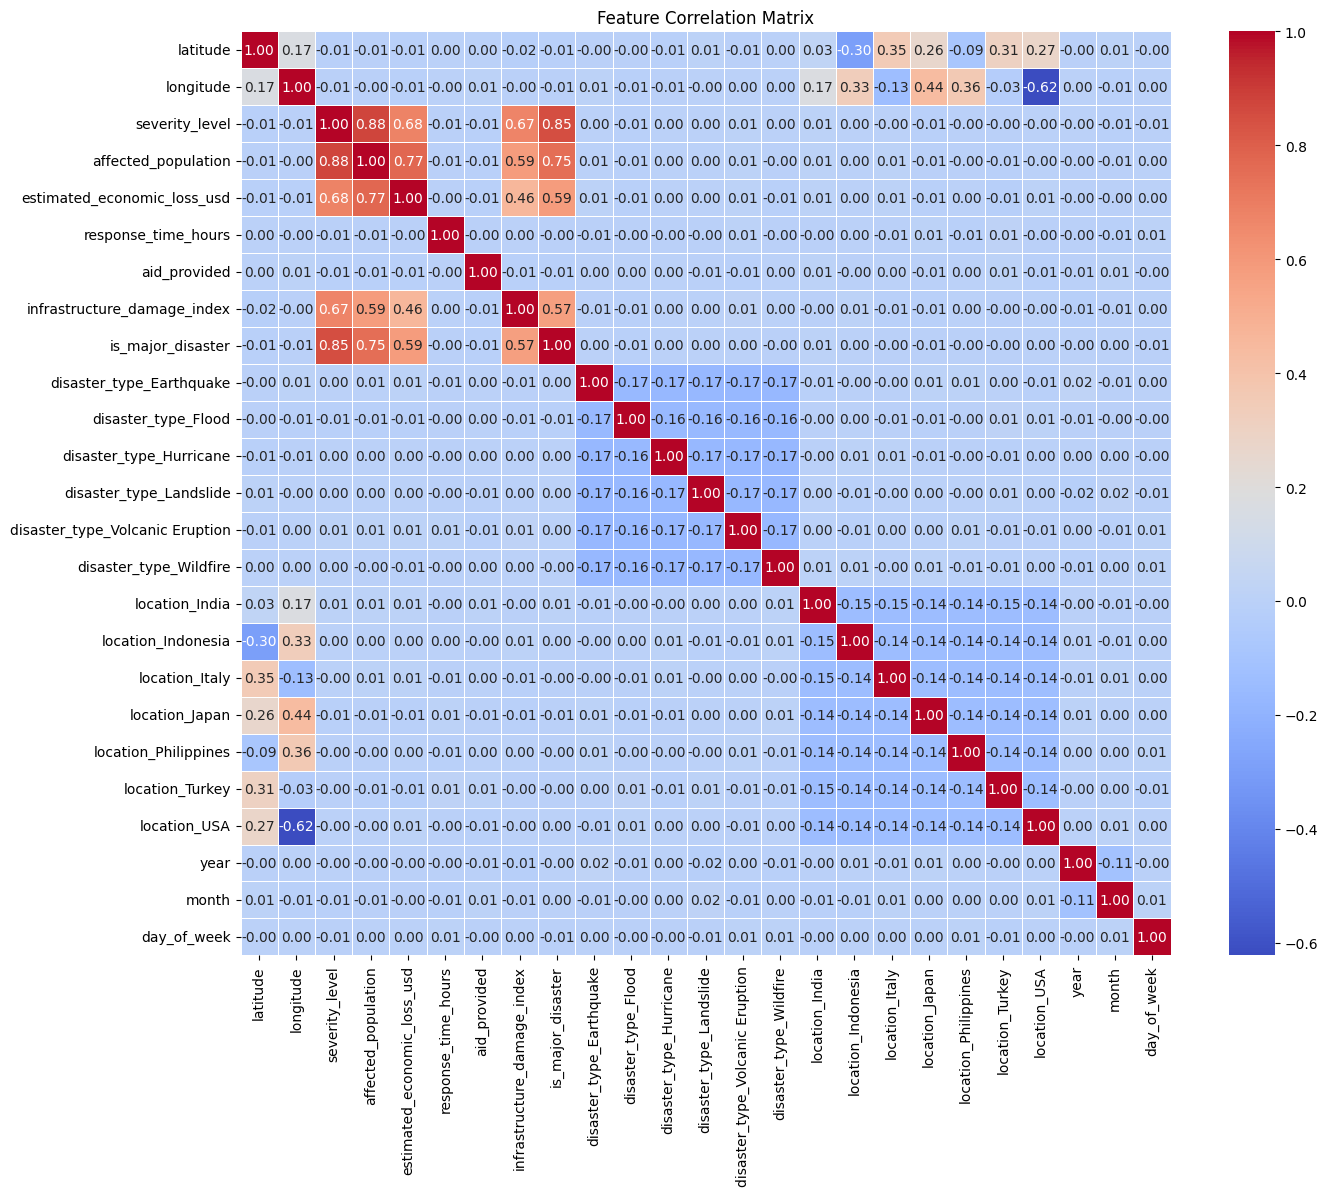

In [ ]:
# Correlation Analysis
correlation_matrix = df.corr()
top_corr_features = correlation_matrix['is_major_disaster'].sort_values(ascending=False)
print("\nTop correlations with target:")
print(top_corr_features)

# Heat Map
corr = df.corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()